In [ ]:
from dev import reload_module_recursive

import datasets
import pvm

reload_module_recursive(datasets)
reload_module_recursive(pvm)

In [5]:
import ibis
import polars as pl
from ibis import deferred as _
from polars.testing import assert_frame_equal

from pvm.measures import CompositeRateMeasure, Measure, QuantityMeasure, RateMeasure
from pvm.pvm import PVM

In [10]:
price = RateMeasure(
    "unit_price",
    definition=(_.volume * _.unit_price).sum() / _.volume.sum(),
    components=[
        QuantityMeasure(
            "price_in_lc",
            definition=(_.volume * _.price_in_lc).sum() / _.volume.sum(),
        ),
        RateMeasure(
            "fx_rate",
            definition=(_.volume * _.fx_rate * _.price_in_lc).sum() / (_.price_in_lc * _.volume).sum(),
        ),
    ],
)

revenue_graph = Measure(
    "revenue",
    definition=_.revenue.sum(),
    reconcile=True,
    components=[
        price,
        QuantityMeasure(
            "volume",
            definition=_.volume.sum(),
        ),
        Measure("flat_fee", definition=_.flat_fee.sum()),
    ],
)

cost_graph = Measure(
    "cost",
    definition=-_.cost.sum(),
    reconcile=False,
    components=[
        QuantityMeasure(
            "cost_volume",
            definition=_.volume.sum(),
            reconcile=False,
            components=[
                RateMeasure(
                    "yield_rate",
                    definition=_.volume.sum() / _.raw_material.sum(),
                ),
                QuantityMeasure(
                    "raw_material",
                    definition=_.raw_material.sum(),
                ),
            ],
        ),
        RateMeasure(
            "unit_cost",
            definition=(-_.unit_cost * _.volume).sum() / _.volume.sum(),
        ),
    ],
)

digraph revenue {
    bgcolor="white"
    rankdir=TB
    dpi=96
    size="8,5"
    node [fontname="Helvetica", margin=0, fontsize=10]
    edge [color="#7F8C8D", penwidth=1.5, arrowsize=0.8]
revenue [
            label=<
<table
border="0"
cellborder="1"
cellspacing="0"
cellpadding="6"
style="rounded"
align="center"
>
<tr>
<td bgcolor="#E8F4F8" align="center">
<font point-size="13" color="#2C3E50">
<b>revenue</b>
</font>
</td>
</tr>

<tr>
<td align="center">
<font point-size="9" color="#7F8C8D">
<i>Measure</i>
</font>
</td>
</tr>
<tr>
<td align="center">
<font point-size="9" color="#34495E">
<b>Formula</b>
</font>
</td>
</tr>
<tr>
<td align="text" balign="left">
<font point-size="9" color="#34495E">
<i><br/>_.revenue.sum()</i>
</font>
</td>
</tr>
</table>
>
            shape=box
            style="filled,rounded"
            fillcolor="#E8F4F8"
            color="#95A5A6"
            penwidth=1
        ]
        "revenue" -> "unit_price"
unit_price [
            label=<
<table
border="0"

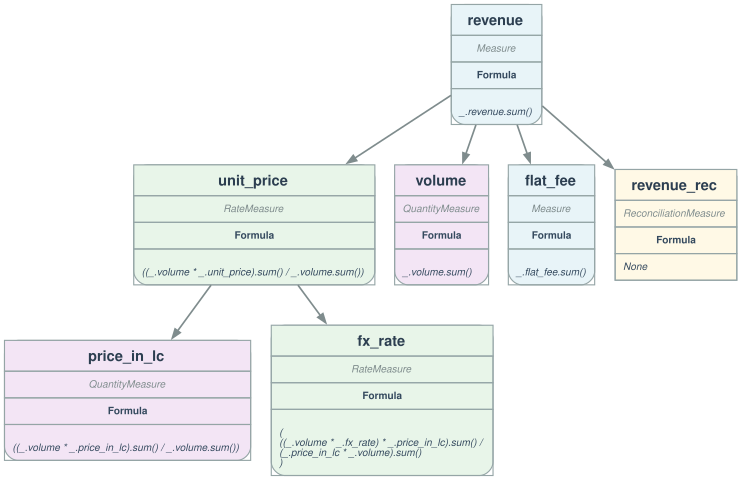

In [4]:
revenue_graph.display(dpi=96, size=(8, 5))

In [8]:
composite_rate = CompositeRateMeasure(
    "unit_profit",
    components=[
        revenue_graph.rate,
        cost_graph.rate,
    ],
)

other_components = revenue_graph.other_components + cost_graph.other_components
components = [composite_rate, revenue_graph.quantity] + other_components

composite_profit_graph = Measure(
    "profit",
    definition=_.revenue.sum() - _.cost.sum(),
    components=components,
)

digraph profit {
    bgcolor="white"
    rankdir=TB
    dpi=20
    node [fontname="Helvetica", margin=0, fontsize=10]
    edge [color="#7F8C8D", penwidth=1.5, arrowsize=0.8]
profit [
            label=<
<table
border="0"
cellborder="1"
cellspacing="0"
cellpadding="6"
style="rounded"
align="center"
>
<tr>
<td bgcolor="#E8F4F8" align="center">
<font point-size="13" color="#2C3E50">
<b>profit</b>
</font>
</td>
</tr>

<tr>
<td align="center">
<font point-size="9" color="#7F8C8D">
<i>Measure</i>
</font>
</td>
</tr>
<tr>
<td align="center">
<font point-size="9" color="#34495E">
<b>Formula</b>
</font>
</td>
</tr>
<tr>
<td align="text" balign="left">
<font point-size="9" color="#34495E">
<i><br/>(_.revenue.sum() - _.cost.sum())</i>
</font>
</td>
</tr>
</table>
>
            shape=box
            style="filled,rounded"
            fillcolor="#E8F4F8"
            color="#95A5A6"
            penwidth=1
        ]
        "profit" -> "unit_profit"
unit_profit [
            label=<
<table
border="0"

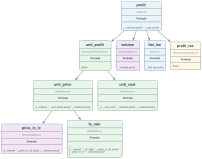

In [9]:
composite_profit_graph.display(dpi=20)

In [11]:
con = ibis.polars.connect({"sales": datasets.sales.raw})
sales = con.table("sales")

obj = PVM().set_data(sales).set_periods(_.year, ["2020", "2021"]).set_hierarchy([_.country, _.sku])

obj.set_graph(composite_profit_graph)

In [12]:
obj.calculate_effects().to_polars()

country,sku,profit_2020,unit_profit_2020,unit_price_2020,price_in_lc_2020,fx_rate_2020,unit_cost_2020,volume_2020,flat_fee_2020,profit_rec_2020,profit_2021,unit_profit_2021,unit_price_2021,price_in_lc_2021,fx_rate_2021,unit_cost_2021,volume_2021,flat_fee_2021,profit_rec_2021,profit__change__2020,unit_profit__change__2020,unit_price__change__2020,price_in_lc__change__2020,fx_rate__change__2020,unit_cost__change__2020,volume__change__2020,flat_fee__change__2020,profit_rec__change__2020,volume__effect__2020,unit_profit__effect__2020,unit_price__effect__2020,unit_cost__effect__2020,price_in_lc__effect__2020,fx_rate__effect__2020,flat_fee__effect__2020
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Saint Vincent and the Grenadin…","""SKU1""",20638.218236,31.703204,96.690872,107.9243,0.895914,-64.987667,650.982093,0.0,0.000002,10291.96468,30.488615,96.563636,102.226497,0.944605,-66.075022,337.567476,0.0,-1.2882e-7,-10346.253556,-1.21459,-0.127235,-5.697803,0.048691,-1.087355,-313.414616,0.0,-0.000002,-9936.247594,-410.005959,-42.950437,-367.055523,-1723.194448,1680.243882,0.0
"""Bouvet Island (Bouvetoya)""","""SKU0""",1049.190177,4.559613,18.011145,13.883225,1.297332,-13.451531,230.105074,0.0,3.9345e-7,1931.447862,4.883659,12.028168,9.948277,1.2090705,-7.144509,391.526218,19.367411,1.0125e-7,882.257686,0.324045,-5.982977,-3.934948,-0.088261,6.307022,161.421145,19.367411,-2.9220e-7,736.018013,126.872263,-2342.492375,2469.364638,-1998.714747,-343.777652,19.367411
"""Burundi""","""SKU3""",6003.937718,20.657324,79.792445,69.419511,1.1494239,-59.135121,291.003995,-7.426082,0.000001,13603.527324,22.62184,82.843375,72.718437,1.139235,-60.221535,600.771132,12.978946,0.000002,7599.589606,1.964516,3.05093,3.298926,-0.010189,-1.086414,309.767137,20.405029,4.3843e-7,6398.960113,1180.224463,1832.910412,-652.685949,2278.042726,-445.13218,20.405029
"""Ecuador""","""SKU2""",1416.565385,15.618694,77.285107,56.124268,1.377035,-61.666413,90.696787,0.0,1.9087e-7,6384.184109,16.651249,78.289836,56.836808,1.37745,-61.638587,382.102752,21.696115,-6.6513e-7,4967.618724,1.032555,1.004729,0.71254,0.000414,0.027825,291.405965,21.696115,-8.5600e-7,4551.380676,394.541933,383.909847,10.632086,374.916731,8.993,21.696115
"""Bouvet Island (Bouvetoya)""","""SKU3""",8681.128492,22.349748,78.619419,60.60087,1.297332,-56.269671,387.563455,19.182827,-0.000001,5693.147644,23.653094,75.726279,62.631814,1.2090705,-52.073185,241.714897,-24.157541,-0.000001,-2987.980848,1.303346,-2.89314,2.030944,-0.088261,4.196486,-145.848558,-43.340368,3.1207e-7,-3259.678552,315.038071,-699.315005,1014.353076,636.872272,-1336.187339,-43.340368
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Burundi""","""SKU2""",9900.534715,16.15903,79.940015,69.547897,1.1494239,-63.780984,612.693618,0.0,0.000002,7918.712281,17.81292,80.703874,70.840422,1.139235,-62.890955,443.963078,10.433554,8.6293e-7,-1981.822435,1.65389,0.76386,1.292525,-0.010189,0.89003,-168.73054,10.433554,-8.4125e-7,-2726.521899,734.265912,339.125553,395.140359,659.577949,-320.452299,10.433554
"""Saint Vincent and the Grenadin…","""SKU4""",428.578061,2.208907,17.563773,19.604311,0.895914,-15.354866,196.530092,-5.538557,8.6965e-7,2770.540632,5.266278,14.544767,15.397727,0.944605,-9.278489,526.090839,0.0,6.1209e-10,2341.962571,3.057371,-3.019006,-4.206583,0.048691,6.076378,329.560747,5.538557,-8.6904e-7,727.968908,1608.455108,-1588.271447,3196.726555,-1982.697554,394.426071,5.538557
"""Bouvet Island (Bouvetoya)""","""SKU4""",1193.389592,4.297,17.202885,13.260208,1.297332,-12.905885,277.72621,0.0,-6.4433e-7,2321.582824,3.988544,15.927495,13.173339,1.2090705,-11.938951,582.062675,0.0,7.5105e-7,1128.193231,-0.308456,-1.27539,-0.086869,-0.088261,0.966934,304.336465,0.0,0.000001,1307.733864,-179.540634,-742.357022,562.816388,-65.597265,-676.75979,0.0


In [13]:
assert_frame_equal(
    obj.calculate_effects().to_polars().sort("customer", "sku"),
    datasets.sales.cost_effects_by_customer_sku.sort("customer", "sku"),
    check_column_order=False,
    check_row_order=True,
    check_dtypes=False,
    atol=1e-2,
)

ColumnNotFoundError: "customer" not found

In [ ]:
unbound_table = ibis.table(sales.schema())
ibis.to_sql(obj.set_data(unbound_table).calculate_effects())

```sql
SELECT
  "t3"."country",
  "t3"."sku",
  "t3"."profit_2020",
  "t3"."unit_profit_2020",
  "t3"."unit_price_2020",
  "t3"."price_in_lc_2020",
  "t3"."fx_rate_2020",
  "t3"."unit_cost_2020",
  "t3"."volume_2020",
  "t3"."flat_fee_2020",
  "t3"."profit_rec_2020",
  "t3"."profit_2021",
  "t3"."unit_profit_2021",
  "t3"."unit_price_2021",
  "t3"."price_in_lc_2021",
  "t3"."fx_rate_2021",
  "t3"."unit_cost_2021",
  "t3"."volume_2021",
  "t3"."flat_fee_2021",
  "t3"."profit_rec_2021",
  "t3"."profit_2021" - "t3"."profit_2020" AS "profit__change__2020",
  "t3"."unit_profit_2021" - "t3"."unit_profit_2020" AS "unit_profit__change__2020",
  "t3"."unit_price_2021" - "t3"."unit_price_2020" AS "unit_price__change__2020",
  "t3"."price_in_lc_2021" - "t3"."price_in_lc_2020" AS "price_in_lc__change__2020",
  "t3"."fx_rate_2021" - "t3"."fx_rate_2020" AS "fx_rate__change__2020",
  "t3"."unit_cost_2021" - "t3"."unit_cost_2020" AS "unit_cost__change__2020",
  "t3"."volume_2021" - "t3"."volume_2020" AS "volume__change__2020",
  "t3"."flat_fee_2021" - "t3"."flat_fee_2020" AS "flat_fee__change__2020",
  "t3"."profit_rec_2021" - "t3"."profit_rec_2020" AS "profit_rec__change__2020",
  CASE
    WHEN (
      COALESCE("t3"."volume_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."volume_2021", 0) <> 0
    )
    THEN (
      "t3"."volume_2021" - "t3"."volume_2020"
    ) * "t3"."unit_profit_2020" * 1.0
    ELSE (
      (
        "t3"."volume_2021" * "t3"."unit_profit_2021"
      ) - (
        "t3"."volume_2020" * "t3"."unit_profit_2020"
      )
    ) * 1.0
  END AS "volume__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."volume_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."volume_2021", 0) <> 0
    )
    THEN (
      "t3"."unit_profit_2021" - "t3"."unit_profit_2020"
    ) * "t3"."volume_2021" * 1.0
    ELSE 0
  END AS "unit_profit__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."volume_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."volume_2021", 0) <> 0
    )
    THEN (
      "t3"."unit_price_2021" - "t3"."unit_price_2020"
    ) * "t3"."volume_2021" * 1.0
    ELSE 0
  END AS "unit_price__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."volume_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."volume_2021", 0) <> 0
    )
    THEN (
      "t3"."unit_cost_2021" - "t3"."unit_cost_2020"
    ) * "t3"."volume_2021" * 1.0
    ELSE 0
  END AS "unit_cost__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."price_in_lc_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."price_in_lc_2021", 0) <> 0
    )
    THEN (
      "t3"."price_in_lc_2021" - "t3"."price_in_lc_2020"
    ) * "t3"."fx_rate_2020" * CASE
      WHEN (
        COALESCE("t3"."volume_2020", 0) <> 0
      )
      AND (
        COALESCE("t3"."volume_2021", 0) <> 0
      )
      THEN "t3"."volume_2021" * 1.0
      ELSE 0
    END
    ELSE (
      (
        "t3"."price_in_lc_2021" * "t3"."fx_rate_2021"
      ) - (
        "t3"."price_in_lc_2020" * "t3"."fx_rate_2020"
      )
    ) * CASE
      WHEN (
        COALESCE("t3"."volume_2020", 0) <> 0
      )
      AND (
        COALESCE("t3"."volume_2021", 0) <> 0
      )
      THEN "t3"."volume_2021" * 1.0
      ELSE 0
    END
  END AS "price_in_lc__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."price_in_lc_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."price_in_lc_2021", 0) <> 0
    )
    THEN (
      "t3"."fx_rate_2021" - "t3"."fx_rate_2020"
    ) * "t3"."price_in_lc_2021" * CASE
      WHEN (
        COALESCE("t3"."volume_2020", 0) <> 0
      )
      AND (
        COALESCE("t3"."volume_2021", 0) <> 0
      )
      THEN "t3"."volume_2021" * 1.0
      ELSE 0
    END
    ELSE 0
  END AS "fx_rate__effect__2020",
  (
    "t3"."flat_fee_2021" - "t3"."flat_fee_2020"
  ) * 1.0 AS "flat_fee__effect__2020"
FROM (
  SELECT
    "t2"."country",
    "t2"."sku",
    COALESCE(SUM("t2"."profit") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "profit_2020",
    COALESCE(SUM("t2"."unit_profit") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "unit_profit_2020",
    COALESCE(SUM("t2"."unit_price") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "unit_price_2020",
    COALESCE(SUM("t2"."price_in_lc") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "price_in_lc_2020",
    COALESCE(SUM("t2"."fx_rate") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "fx_rate_2020",
    COALESCE(SUM("t2"."unit_cost") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "unit_cost_2020",
    COALESCE(SUM("t2"."volume") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "volume_2020",
    COALESCE(SUM("t2"."flat_fee") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "flat_fee_2020",
    COALESCE(SUM("t2"."profit_rec") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "profit_rec_2020",
    COALESCE(SUM("t2"."profit") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "profit_2021",
    COALESCE(SUM("t2"."unit_profit") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "unit_profit_2021",
    COALESCE(SUM("t2"."unit_price") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "unit_price_2021",
    COALESCE(SUM("t2"."price_in_lc") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "price_in_lc_2021",
    COALESCE(SUM("t2"."fx_rate") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "fx_rate_2021",
    COALESCE(SUM("t2"."unit_cost") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "unit_cost_2021",
    COALESCE(SUM("t2"."volume") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "volume_2021",
    COALESCE(SUM("t2"."flat_fee") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "flat_fee_2021",
    COALESCE(SUM("t2"."profit_rec") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "profit_rec_2021"
  FROM (
    SELECT
      "t1"."country",
      "t1"."sku",
      CAST("t1"."year" AS TEXT) AS "__period__",
      SUM("t1"."revenue") - SUM("t1"."cost") AS "profit",
      (
        SUM("t1"."volume" * "t1"."unit_price") / SUM("t1"."volume")
      ) + 0 + (
        SUM(-(
          "t1"."unit_cost"
        ) * "t1"."volume") / SUM("t1"."volume")
      ) AS "unit_profit",
      SUM("t1"."volume" * "t1"."unit_price") / SUM("t1"."volume") AS "unit_price",
      SUM("t1"."volume" * "t1"."price_in_lc") / SUM("t1"."volume") AS "price_in_lc",
      SUM("t1"."volume" * "t1"."fx_rate" * "t1"."price_in_lc") / SUM("t1"."price_in_lc" * "t1"."volume") AS "fx_rate",
      SUM(-(
        "t1"."unit_cost"
      ) * "t1"."volume") / SUM("t1"."volume") AS "unit_cost",
      SUM("t1"."volume") AS "volume",
      SUM("t1"."flat_fee") AS "flat_fee",
      (
        SUM("t1"."revenue") - SUM("t1"."cost")
      ) - (
        (
          (
            (
              SUM("t1"."volume" * "t1"."unit_price") / SUM("t1"."volume")
            ) + 0 + (
              SUM(-(
                "t1"."unit_cost"
              ) * "t1"."volume") / SUM("t1"."volume")
            )
          ) * SUM("t1"."volume")
        ) + (
          SUM("t1"."flat_fee") + 0
        )
      ) AS "profit_rec"
    FROM (
      SELECT
        *
      FROM "unbound_table_0" AS "t0"
      WHERE
        CAST("t0"."year" AS TEXT) IN ('2020', '2021')
    ) AS "t1"
    GROUP BY
      1,
      2,
      3
  ) AS "t2"
  GROUP BY
    1,
    2
) AS "t3"
```

In [ ]:
obj.calculate_effects().to_polars().select(
    "sku",
    "country",
    "unit_price__effect__2020",
    "price_in_lc__effect__2020",
    "fx_rate__effect__2020",
).with_columns(
    (pl.col("unit_price__effect__2020") - pl.col("price_in_lc__effect__2020") - pl.col("fx_rate__effect__2020")).alias(
        "diff",
    ),
).sort(["country", "sku"])

IbisError: Expression contains unbound tables and therefore cannot be executed. Use `<backend>.execute(expr)` to execute against an explicit backend, or rebuild the expression using bound tables instead.